# Feature Engineeering.

---

## Importing Libraries:

In [1]:
import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from statsmodels.stats.outliers_influence import variance_inflation_factor

import warnings
warnings.filterwarnings('ignore')

## Importing Dataset:

In [2]:
data = pd.read_csv("Laptop Dataset.csv")

In [3]:
data.sample(5, random_state=69)

,Brand,Series,Weight (Kg),Operating System,Display Size (Inches),Display Resolution,Pixel Density (PPI),Display Type,Display Touchscreen,Processor,Clock Speed (GHz),Graphic Processor,RAM (GB),RAM Type,RAM Speed (MHz),SSD Capacity (GB),Refresh Rate (Hz),Graphics Memory (GB),HDD Capacity (GB),Price (Rs)
914,Avita,Magus,1.14,Windows,12.5,1920 x 1080,176.0,LED,No,Intel Celeron Dual Core N3350,1.1,Intel HD 500,4.0,DDR3,1600.0,64.0,NaN,NaN,NaN,15871.0
7918,Microsoft,NaN,1.00,Windows,13.0,2880 x 1920,266.0,NaN,Yes,Intel Core i7-1255U (12th Gen),4.7,Intel Iris Xe,16.0,LPDDR5,NaN,512.0,120.0,NaN,NaN,149999.0
5283,Asus,Zenbook 14,1.39,Windows,14.0,2880 x 1800,243.0,OLED,Yes,Intel Core i5-1340P (13th Gen),4.6,Intel Iris Xe,16.0,LPDDR5,NaN,512.0,90.0,NaN,NaN,83990.0
6730,Asus,ROG Zephyrus Duo 15,2.48,Windows,15.6,1920 x 1080,141.0,LED,No,Intel Core i7-10875H (10th Gen),2.3,NVIDIA GeForce RTX 2070 Super with Max-Q Design,32.0,DDR4,3200.0,1024.0,300.0,8.0,NaN,360990.0
1429,Lenovo,NaN,1.55,DOS,14.0,1366 x 768,112.0,LED,No,Intel Core i3-8130U (8th Gen),2.2,Intel UHD 620,4.0,DDR4,NaN,NaN,NaN,NaN,1024.0,29490.0


## Data Cleaning:

In [4]:
data.drop(columns=['Series', 'Display Size (Inches)', 'Display Resolution'], inplace=True)

In [5]:
data.drop_duplicates(keep='first', inplace=True)

In [6]:
data.dropna(subset=['Price (Rs)'], inplace=True)

## Numerical Features:

In [7]:
num_df = data[['Weight (Kg)', 'Pixel Density (PPI)', 'Clock Speed (GHz)', 'RAM (GB)', 'RAM Speed (MHz)', 'SSD Capacity (GB)', 'Refresh Rate (Hz)', 'Graphics Memory (GB)', 'HDD Capacity (GB)', 'Price (Rs)']]

In [8]:
num_df['Missing Ram Speed'] = num_df['RAM Speed (MHz)'].isna().astype(int)

num_df['Missing Refresh Rate'] = num_df['Refresh Rate (Hz)'].isna().astype(int)

In [9]:
impute_median = Pipeline(steps=[
    ('impute_median', SimpleImputer(strategy='median'))
])

impute_constant_value = Pipeline(steps=[
    ('impute_constant', SimpleImputer(strategy='constant', fill_value=0))
])

In [10]:
numerical_features = ColumnTransformer(transformers=[
    ('Impute_Median', impute_median, ['Weight (Kg)', 'Pixel Density (PPI)', 'Clock Speed (GHz)', 'RAM Speed (MHz)', 'Refresh Rate (Hz)']),
    ('Impute_Constant', impute_constant_value, ['Graphics Memory (GB)', 'SSD Capacity (GB)', 'HDD Capacity (GB)'])
], remainder='passthrough')

In [11]:
num_df = numerical_features.fit_transform(num_df)

num_df_cols = numerical_features.get_feature_names_out()

num_df = pd.DataFrame(num_df, columns=num_df_cols, index=data.index)
num_df.rename(columns={
    'Impute_Median__Weight (Kg)' : 'Weight',
    'Impute_Median__Pixel Density (PPI)' : 'PPI',
    'Impute_Median__Clock Speed (GHz)' : 'Clock Speed',
    'Impute_Median__RAM Speed (MHz)' : 'RAM Speed',
    'Impute_Median__Refresh Rate (Hz)' : 'Refresh Rate',
    'remainder__Price (Rs)' : 'Price',
    'Impute_Constant__Graphics Memory (GB)' : 'Graphics Memory',
    'Impute_Constant__SSD Capacity (GB)' : 'SSD',
    'Impute_Constant__HDD Capacity (GB)' : 'HDD',
    'remainder__RAM (GB)' : 'RAM',
    'remainder__Missing Ram Speed' : 'Missing RAM Speed',
    'remainder__Missing Refresh Rate' : 'Missing Refresh Rate'
}, inplace=True)

In [12]:
num_df.sample(10, random_state=69)

,Weight,PPI,Clock Speed,RAM Speed,Refresh Rate,Graphics Memory,SSD,HDD,RAM,Price,Missing RAM Speed,Missing Refresh Rate
4040,2.10,141.0,2.8,3200.0,144.0,6.0,512.0,0.0,8.0,69999.0,1.0,0.0
758,1.51,224.0,4.1,3200.0,120.0,0.0,512.0,0.0,16.0,139990.0,1.0,1.0
958,2.10,141.0,3.3,3200.0,144.0,4.0,512.0,0.0,8.0,51990.0,1.0,0.0
5530,1.83,141.0,2.4,2666.0,120.0,2.0,256.0,1024.0,8.0,64590.0,0.0,1.0
344,2.30,141.0,4.7,3200.0,300.0,6.0,1024.0,0.0,16.0,87044.0,1.0,0.0
2121,1.39,157.0,2.1,3200.0,120.0,0.0,512.0,0.0,8.0,47990.0,1.0,1.0
1608,2.20,141.0,4.7,4800.0,144.0,6.0,512.0,0.0,16.0,85990.0,0.0,0.0
4117,1.40,157.0,2.8,3200.0,120.0,0.0,512.0,0.0,8.0,51999.0,1.0,1.0
7281,1.62,141.0,4.6,4800.0,60.0,0.0,512.0,0.0,16.0,59490.0,0.0,0.0
1801,2.60,141.0,2.3,2666.0,120.0,4.0,256.0,1024.0,8.0,85990.0,0.0,1.0


## Categorical Features:

In [13]:
cat_df = data[['Brand', 'Operating System', 'Display Type', 'Display Touchscreen', 'Processor', 'Graphic Processor', 'RAM Type']]

In [14]:
brand_count_percentage = (cat_df['Brand'].value_counts() / len(cat_df) * 100)

cat_df.loc[cat_df['Brand'].map(brand_count_percentage) <= 1, 'Brand'] = 'Other'

In [15]:
os_count_percentage = (cat_df['Operating System'].value_counts() / len(cat_df) * 100)

cat_df.loc[cat_df['Operating System'].map(os_count_percentage) <= 1, 'Operating System'] = 'Other'

In [16]:
display_count_percentage = (cat_df['Display Type'].value_counts() / len(cat_df) * 100)

cat_df.loc[cat_df['Display Type'].map(display_count_percentage) <= 0.1, 'Display Type'] = 'Other'

In [17]:
ram_count_percentage = (cat_df['RAM Type'].value_counts() / len(cat_df) * 100)

cat_df.loc[cat_df['RAM Type'].map(ram_count_percentage) <= 1, 'RAM Type'] = 'Other'

In [18]:
cat_df['CPU Brand'] = pd.Series(np.nan, index=data.index, dtype=object)

cat_df.loc[cat_df['Processor'].str.lower().str.contains('intel|inte core', na=False), 'CPU Brand'] = 'intel'
cat_df.loc[cat_df['Processor'].str.lower().str.contains('amd|ryzen|apu|athlon|radeon', na=False), 'CPU Brand'] = 'amd'
cat_df.loc[cat_df['Processor'].str.lower().str.contains('apple', na=False), 'CPU Brand'] = 'apple'
cat_df.loc[cat_df['Processor'].str.lower().str.contains('qualcomm|snapdragon|microsoft', na=False), 'CPU Brand'] = 'qualcomm'
cat_df.loc[cat_df['Processor'].str.lower().str.contains('mediatek', na=False), 'CPU Brand'] = 'mediatek'


# -----------------------------------------------------------------------------------------------------------------------------------------------------


cat_df['CPU Segment'] = pd.Series(np.nan, index=data.index, dtype=object)


norm = (cat_df['Processor'].str.lower().str.replace('-', ' ', regex=False).str.replace(r'\s+', ' ', regex=True).str.strip())

low_tier_cpu = [
    r'core i3\b', r'\bcore 3\b', r'\bcore m3\b', r'\bcore m5\b',
    r'celeron', r'pentium', r'\batom\b',
    r'\ba4\b', r'\ba6\b', r'\ba8\b', r'\ba9\b', r'\ba10\b', r'\ba12\b',
    r'\be1\b', r'\be2\b', r'\bfx\b',
    r'ryzen 3\b', r'athlon(?! gold)(?! silver)', r'athlon gold', r'athlon silver',
    r'apu\b(?!.*ryzen)',
    r'snapdragon 7c', r'snapdragon 665', r'snapdragon 835',
    r'kompanio', r'\bmt8', r'microsoft sq1',
    r'p60t', r'athon',
    r'dual core 3020e', r'\bi3\b',
]

mid_tier_cpu = [
    r'core i5\b', r'\bcore 5\b', r'core ultra 5', r'ryzen 5\b', r'\bi5\b',
    r'snapdragon x\b', r'snapdragon x plus',
    r'^apple m1$', r'^apple m2$', r'^apple m3$', r'^apple m3 chip$', r'^apple m4$',
]

high_tier_cpu = [
    r'core i7\b', r'core i9\b', r'\bcore 7\b', r'core ultra 7', r'core ultra 9',
    r'ryzen 7\b', r'ryzen 9\b', r'ryzen ai 7', r'ryzen ai 9',
    r'xeon', r'xenon',
    r'\bi7\b', r'\bi9\b',
    r'snapdragon x elite', r'snapdragon.*835',
    r'\bm1 pro\b', r'\bm1 max\b', r'\bm2 pro\b', r'\bm2 max\b',
    r'\bm3 pro\b', r'\bm3 max\b', r'\bm4 pro\b', r'\bm4 max\b',
]

cat_df.loc[norm.str.contains('|'.join(low_tier_cpu),  na=False, regex=True), 'CPU Segment'] = 'low'
cat_df.loc[norm.str.contains('|'.join(mid_tier_cpu),  na=False, regex=True), 'CPU Segment'] = 'mid'
cat_df.loc[norm.str.contains('|'.join(high_tier_cpu), na=False, regex=True), 'CPU Segment'] = 'high'


# -----------------------------------------------------------------------------------------------------------------------------------------------------


cat_df['CPU Series'] = pd.Series(np.nan, index=data.index, dtype=object)

s = cat_df['Processor'].str.lower()

low_series = [
    r'\d+y\b', r'\d+u\b', r'\d+ug\d\b', r'\d+g\d\b', r'\d+g\b', r'\bn\d{3,4}\b',
    r'z\d{3,4}[a-z]?\b', r'\d+e\b', r'\d+c\b', r'\d+v\b', r'\d+ng\d\b',
    r'\d+du\b', r't\d{4}\b',
    r'mediatek',
    r'qualcomm|snapdragon|microsoft',
]
mid_series = [
    r'\d+p\b',
    r'snapdragon.*plus', 
    r'^apple', 
]
high_series = [
    r'\d+h[skxfqi]?\b',
    r'\bhx\b',     
    r'\d+mq\b',
    r'snapdragon.*elite',
    r'apple.*pro|apple.*max',
]

cat_df.loc[s.str.contains('|'.join(low_series),  na=False, regex=True), 'CPU Series'] = 'low'
cat_df.loc[s.str.contains('|'.join(mid_series),  na=False, regex=True), 'CPU Series'] = 'mid'
cat_df.loc[s.str.contains('|'.join(high_series), na=False, regex=True), 'CPU Series'] = 'high'

brand_amd_intel = s.str.contains('intel|inte core|amd|ryzen|apu|athlon', na=False)
fallback_mask = cat_df['CPU Series'].isna() & brand_amd_intel & cat_df['CPU Segment'].notna()
cat_df.loc[fallback_mask, 'CPU Series'] = cat_df.loc[fallback_mask, 'CPU Segment']


# -----------------------------------------------------------------------------------------------------------------------------------------------------


cat_df['CPU Generation'] = np.nan

s = cat_df['Processor'].str.lower()

explicit_gen = s.str.extract(r'\(?\s*(\d+)\w{0,2}\s*gen\.?\s*\)?', expand=False)
cat_df.loc[explicit_gen.notna(), 'CPU Generation'] = explicit_gen[explicit_gen.notna()]

series_n = s.str.extract(r'series\s*(\d+)', expand=False)
mask = cat_df['CPU Generation'].isna() & series_n.notna()
cat_df.loc[mask, 'CPU Generation'] = (series_n[mask].astype(int) + 14).astype(str)

mask = cat_df['CPU Generation'].isna() & s.str.contains('core ultra', na=False)
cat_df.loc[mask, 'CPU Generation'] = '1'

model_num = s.str.extract(r'i[3579]\s*-?\s*(\d{4,5})', expand=False)
def infer_intel_gen(d):
    if pd.isna(d):
        return np.nan
    return d[:2] if d[:2] in ('10','11','12','13','14') else d[0]
inferred = model_num.apply(infer_intel_gen)
mask = cat_df['CPU Generation'].isna() & inferred.notna()
cat_df.loc[mask, 'CPU Generation'] = inferred[mask]

ryzen_num = s.str.extract(r'ryzen\s*[3579]\s*-?\s*(\d{4})', expand=False)
mask = cat_df['CPU Generation'].isna() & ryzen_num.notna()
cat_df.loc[mask, 'CPU Generation'] = ryzen_num[mask].str[0]

mask = cat_df['CPU Generation'].isna() & s.str.contains('ryzen ai', na=False)
cat_df.loc[mask, 'CPU Generation'] = '9'

apple_num = s.str.extract(r'\bm(\d)\b', expand=False)
mask = cat_df['CPU Generation'].isna() & s.str.contains('apple', na=False)
cat_df.loc[mask, 'CPU Generation'] = apple_num[mask]

cat_df.drop(columns=['Processor'], inplace=True)

In [19]:
cat_df['GPU Brand'] = pd.Series(np.nan, index=data.index, dtype=object)

cat_df.loc[cat_df['Graphic Processor'].str.lower().str.contains('nvidia|geforce|nividia', na=False), 'GPU Brand'] = 'nvidia'
cat_df.loc[cat_df['Graphic Processor'].str.lower().str.contains('amd|radeon|ati', na=False), 'GPU Brand'] = 'amd'
cat_df.loc[cat_df['Graphic Processor'].str.lower().str.contains('intel', na=False), 'GPU Brand'] = 'intel'
cat_df.loc[cat_df['Graphic Processor'].str.lower().str.contains('apple', na=False), 'GPU Brand'] = 'apple'
cat_df.loc[cat_df['Graphic Processor'].str.lower().str.contains('qualcomm|adreno', na=False), 'GPU Brand'] = 'qualcomm'
cat_df.loc[cat_df['Graphic Processor'].str.lower().str.contains('mediatek|arm', na=False), 'GPU Brand'] = 'mediatek'


# -----------------------------------------------------------------------------------------------------------------------------------------------------


cat_df['GPU Segment'] = pd.Series(np.nan, index=data.index, dtype=object)

norm = cat_df['Graphic Processor'].str.lower().str.replace(r'[\s\-]+', '', regex=True)

low_tier_gpu = [
    'intelhd', 'inteluhd', 'intelgfx', 'intelgraphics', 'intelintegrated', 'inteluma', 'iris', '^intel$',
    'radeongraphics', 'amdgraphics', 'amdintegrated', 'radeonhd', 'amdradeonhd', 'radeonr2', 'radeonr3', 'radeonr4', 'radeonr5', 'radeonr7', 'athlon', 'vega2', 'vega3', 'vega5', 'vega6', 'vega7', 'vega8', 'vega10', 'vega$', 'radeon610', 'radeon430', 'radeon520', 'radeon530', 'radeon535', 'radeon540', 'radeon3250u', 'radeon$', 'radeonuhd', '940mx', 'r17m', 'r16m', 'atiexopro', 'atimobility',
    'geforce8', 'geforce92', 'geforce93', 'geforce94', 'geforcegt7', 'geforcegt8', 'geforcegt9',
    'mx110', 'mx130', 'mx150', 'mx230', 'mx250', 'mx330',
    'gtx850m', 'gtx860m', 'gtx960', 'gtx980m', 'gtx1050', 'gtx1650',
    'rtx2050', 'rtx1650',
    'quadrot50$', 'quadromx130',
    'mali', 'adreno', 'mediatek', 'n16s', 'n16v',
    'appleintegrated', 'qualcommintegrated',
]

mid_tier_gpu = [
    'mx350', 'mx450', 'mx550', 'mx570',
    'gtx1060', 'gtx1660','geforce1060', 'geforce1650',
    'gtx2060', 'gtx3050', 'gtx3060',
    'rtx2060', 'rtx3050', 'rtx3060', 'rtx4050', 'rtx4060', 'rtx3000',
    'rtxa1000', 'rtxa2000', 'rtxa500', 'nvidiaa2000',
    'quadrot5', 'quadrot6', 'quadrot1', 'quadrot2', 't500', 't550', 't600', 't1200', 'quadrop1000', 'quadrop620', 'geforcep620', 'quadrortx3000',
    'rx550', 'rx560', 'rx580', 'rx640', 'rx5500m', 'rx5600m','rx6500m', 'rx6550m', 'rx6600m', 'rx6650m',
    'radeon660m', 'radeon680m', 'radeon740m', 'radeon760m', 'radeon780m', 'radeon860m', 'radeon880m', 'radeon890m', 'radeonpro', 'vegamgl',
    'arc130v', 'arc140v', 'arc140t', 'arca370m', 'arca530m', '^intelarc$', 'intelintegratedarc', 'intelintegratedirisxe', 'irisxe',
    'applem1', '^applem2$', 'applem2integrated', '^applem3$', '^applem4$',
]

high_tier_gpu = [
    'gtx1070', 'gtx1080', 'rtx2070', 'rtx2080', 'rtx3070', 'rtx3080',
    'rtx4070', 'rtx4080', 'rtx4090', 'rtx5070', 'rtx5080', 'rtx5090',
    'rtx1000ada', 'rtx2000ada', 'rtx3000ada', 'rtx3500ada', 'rtx4000ada', 'rtx500ada', 'rtx5000ada',
    'quadrortx5000',
    'rx6700m', 'rx6700s', 'rx6800m', 'rx6800s', 'rx7600s',
    'applem2pro', 'applem2max', r'apple\d+coregpu',
]

cat_df.loc[norm.str.contains('|'.join(low_tier_gpu),  na=False, regex=True), 'GPU Segment'] = 'low'
cat_df.loc[norm.str.contains('|'.join(mid_tier_gpu),  na=False, regex=True), 'GPU Segment'] = 'mid'
cat_df.loc[norm.str.contains('|'.join(high_tier_gpu), na=False, regex=True), 'GPU Segment'] = 'high'

cat_df.drop(columns=['Graphic Processor'], inplace=True)

In [20]:
impute_cat = Pipeline(steps=[
    ('impute_cat', SimpleImputer(strategy='most_frequent'))
])

impute_num = Pipeline(steps=[
    ('impute_num', SimpleImputer(strategy='constant', fill_value=0))
])

In [21]:
categorical_features = ColumnTransformer(transformers=[
    ('Impute_Cat', impute_cat, ['Display Type', 'Display Touchscreen', 'RAM Type', 'GPU Brand', 'GPU Segment']),
    ('Impute_Num', impute_num, ['CPU Generation'])
], remainder='passthrough')

In [22]:
cat_df = categorical_features.fit_transform(cat_df)

cat_df_cols = categorical_features.get_feature_names_out()

cat_df = pd.DataFrame(cat_df, columns=cat_df_cols, index=data.index)

cat_df.rename(columns={
    'Impute_Cat__Display Type' : 'Display Type',
    'Impute_Cat__Display Touchscreen' : 'Display Touchscreen',
    'Impute_Cat__RAM Type' : 'RAM Type',
    'Impute_Cat__GPU Brand' : 'GPU Brand',
    'Impute_Cat__GPU Segment' : 'GPU Segment',
    'Impute_Num__CPU Generation' : 'CPU Generation',
    'remainder__Brand' : 'Brand',
    'remainder__Operating System' : 'Operating System',
    'remainder__CPU Brand' : 'CPU Brand',
    'remainder__CPU Segment' : 'CPU Segment',
    'remainder__CPU Series' : 'CPU Series'
}, inplace=True)

In [23]:
cat_df['CPU Generation'] = cat_df['CPU Generation'].astype(int)

cat_df.sample(10, random_state=69)

,Display Type,Display Touchscreen,RAM Type,GPU Brand,GPU Segment,CPU Generation,Brand,Operating System,CPU Brand,CPU Segment,CPU Series
4040,LED,No,DDR5,nvidia,mid,13,Acer,Windows,intel,mid,high
758,Other,No,Other,intel,low,3,Apple,macOS,apple,mid,mid
958,TFT LCD,No,DDR4,nvidia,low,12,Acer,Windows,intel,mid,high
5530,LED,No,DDR4,nvidia,low,11,Dell,Windows,intel,mid,low
344,LED,No,DDR5,nvidia,mid,6,Asus,Windows,amd,high,high
2121,LED,No,DDR4,amd,low,3,Asus,Windows,amd,mid,low
1608,LED,No,DDR5,nvidia,mid,7,Asus,Windows,amd,high,high
4117,TFT LCD,No,LPDDR5,intel,mid,13,Acer,Windows,intel,mid,low
7281,LED,No,LPDDR5,intel,low,13,Lenovo,Windows,intel,mid,high
1801,LED,No,DDR4,nvidia,low,8,Asus,Windows,intel,mid,high


## Final Clean Dataset:

In [24]:
final_df = pd.concat([num_df, cat_df], axis=1)

In [25]:
final_df.sample(10, random_state=69)

,Weight,PPI,Clock Speed,RAM Speed,Refresh Rate,Graphics Memory,SSD,HDD,RAM,Price,...,Display Touchscreen,RAM Type,GPU Brand,GPU Segment,CPU Generation,Brand,Operating System,CPU Brand,CPU Segment,CPU Series
4040,2.10,141.0,2.8,3200.0,144.0,6.0,512.0,0.0,8.0,69999.0,...,No,DDR5,nvidia,mid,13,Acer,Windows,intel,mid,high
758,1.51,224.0,4.1,3200.0,120.0,0.0,512.0,0.0,16.0,139990.0,...,No,Other,intel,low,3,Apple,macOS,apple,mid,mid
958,2.10,141.0,3.3,3200.0,144.0,4.0,512.0,0.0,8.0,51990.0,...,No,DDR4,nvidia,low,12,Acer,Windows,intel,mid,high
5530,1.83,141.0,2.4,2666.0,120.0,2.0,256.0,1024.0,8.0,64590.0,...,No,DDR4,nvidia,low,11,Dell,Windows,intel,mid,low
344,2.30,141.0,4.7,3200.0,300.0,6.0,1024.0,0.0,16.0,87044.0,...,No,DDR5,nvidia,mid,6,Asus,Windows,amd,high,high
2121,1.39,157.0,2.1,3200.0,120.0,0.0,512.0,0.0,8.0,47990.0,...,No,DDR4,amd,low,3,Asus,Windows,amd,mid,low
1608,2.20,141.0,4.7,4800.0,144.0,6.0,512.0,0.0,16.0,85990.0,...,No,DDR5,nvidia,mid,7,Asus,Windows,amd,high,high
4117,1.40,157.0,2.8,3200.0,120.0,0.0,512.0,0.0,8.0,51999.0,...,No,LPDDR5,intel,mid,13,Acer,Windows,intel,mid,low
7281,1.62,141.0,4.6,4800.0,60.0,0.0,512.0,0.0,16.0,59490.0,...,No,LPDDR5,intel,low,13,Lenovo,Windows,intel,mid,high
1801,2.60,141.0,2.3,2666.0,120.0,4.0,256.0,1024.0,8.0,85990.0,...,No,DDR4,nvidia,low,8,Asus,Windows,intel,mid,high


## EDA on New Features:

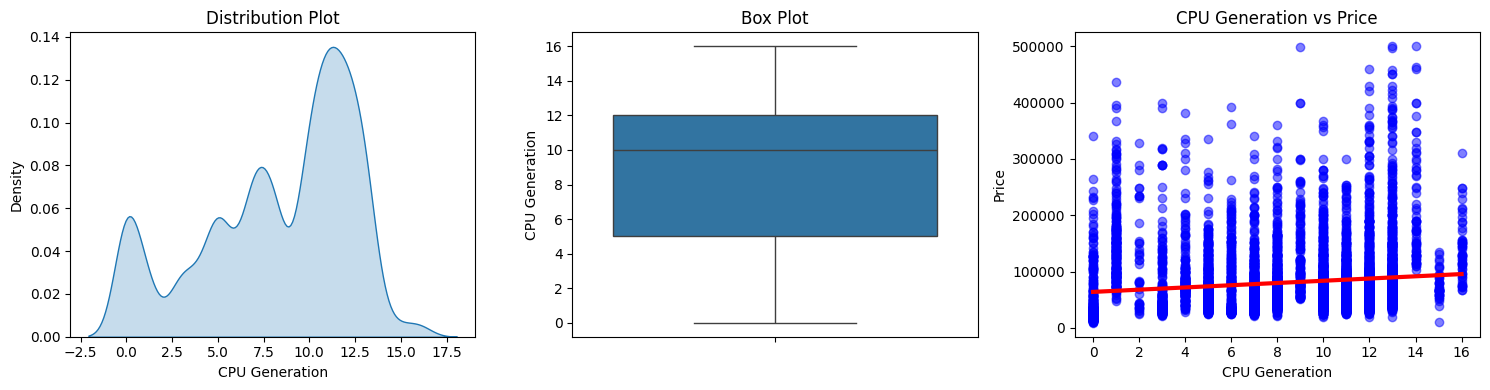

In [26]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(15,4))

sns.kdeplot(data=final_df, x='CPU Generation', fill=True, ax=ax[0])
ax[0].set_title("Distribution Plot")

sns.boxplot(data=final_df, y='CPU Generation', ax=ax[1])
ax[1].set_title("Box Plot")

sns.regplot(data=final_df, x='CPU Generation', y='Price',scatter_kws={'color' : 'blue', 'alpha' : 0.5}, line_kws={'color' : 'red', 'linewidth' : 3}, ax=ax[2])
ax[2].set_title("CPU Generation vs Price")

plt.tight_layout()
plt.show()

In [27]:
final_df[['CPU Generation', 'Price']].corr()

,CPU Generation,Price
CPU Generation,1.000000,0.138312
Price,0.138312,1.000000


#### **CPU Generation -> DROP.**

- Not very strong relation with our target feature.

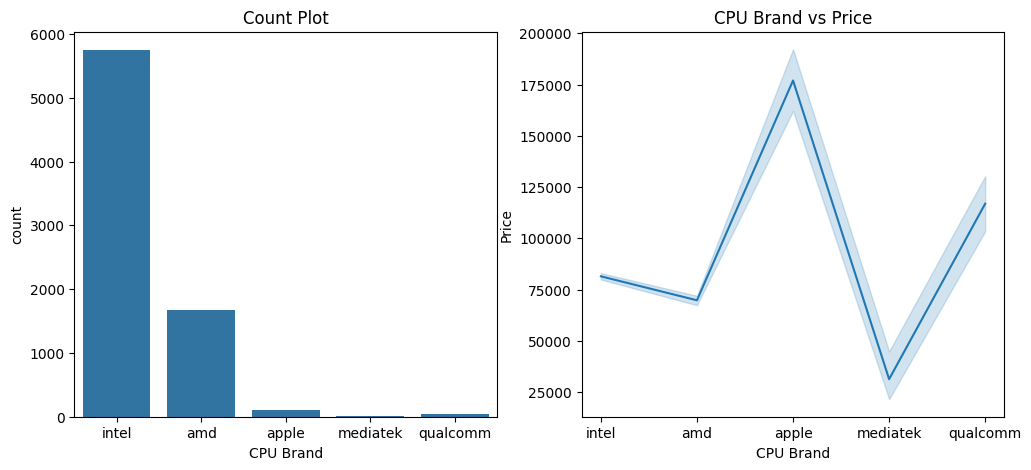

In [28]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,5))

sns.countplot(data=final_df, x='CPU Brand', ax=ax[0])
ax[0].set_title('Count Plot')

sns.lineplot(data=final_df, x='CPU Brand', y='Price', ax=ax[1])
ax[1].set_title('CPU Brand vs Price')

plt.show()

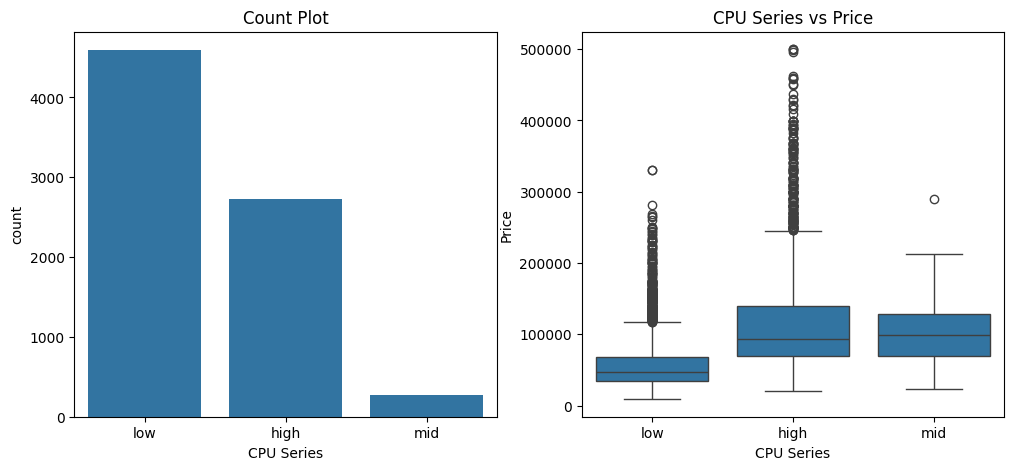

In [29]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,5))

sns.countplot(data=final_df, x='CPU Series', ax=ax[0])
ax[0].set_title('Count Plot')

sns.boxplot(data=final_df, x='CPU Series', y='Price', ax=ax[1])
ax[1].set_title('CPU Series vs Price')

plt.show()

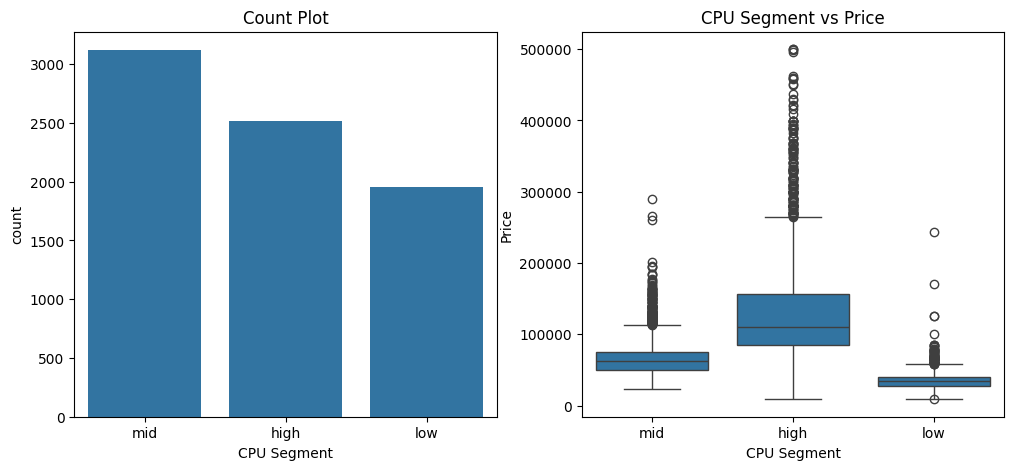

In [30]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,5))

sns.countplot(data=final_df, x='CPU Segment', ax=ax[0])
ax[0].set_title('Count Plot')

sns.boxplot(data=final_df, x='CPU Segment', y='Price', ax=ax[1])
ax[1].set_title('CPU Segment vs Price')

plt.show()

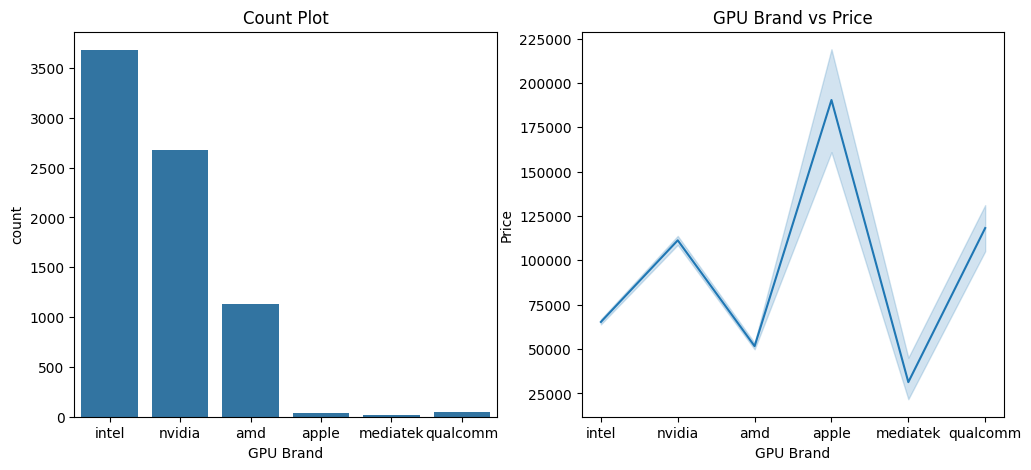

In [31]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,5))

sns.countplot(data=final_df, x='GPU Brand', ax=ax[0])
ax[0].set_title('Count Plot')

sns.lineplot(data=final_df, x='GPU Brand', y='Price', ax=ax[1])
ax[1].set_title('GPU Brand vs Price')

plt.show()

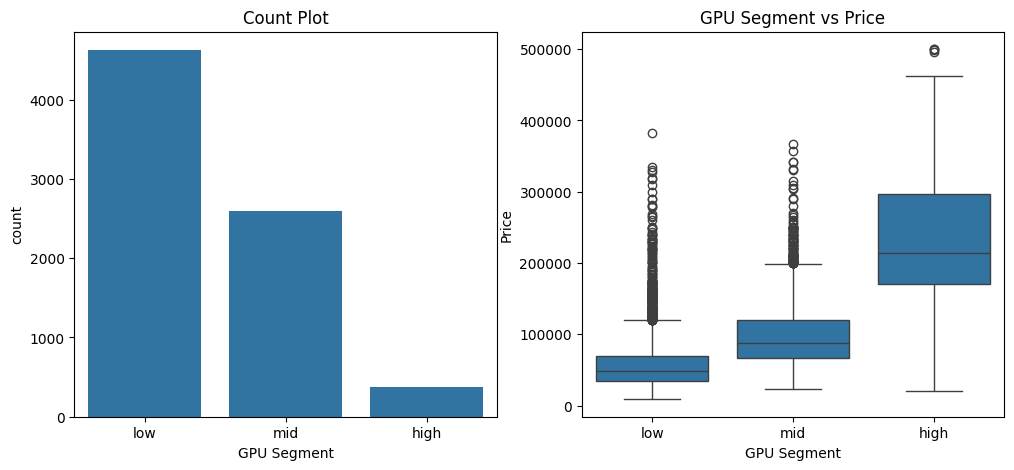

In [32]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,5))

sns.countplot(data=final_df, x='GPU Segment', ax=ax[0])
ax[0].set_title('Count Plot')

sns.boxplot(data=final_df, x='GPU Segment', y='Price', ax=ax[1])
ax[1].set_title('GPU Segment vs Price')

plt.show()

## Extracting Final Clean Dataset:

In [33]:
final_df.drop(columns=['CPU Generation'], inplace=True)

final_df.to_csv('Cleaned Laptop Dataset.csv')

In [34]:
final_df

,Weight,PPI,Clock Speed,RAM Speed,Refresh Rate,Graphics Memory,SSD,HDD,RAM,Price,...,Display Type,Display Touchscreen,RAM Type,GPU Brand,GPU Segment,Brand,Operating System,CPU Brand,CPU Segment,CPU Series
0,1.41,157.0,4.2,3200.0,120.0,0.0,512.0,0.0,16.0,71990.0,...,LED,No,DDR4,intel,low,HP,Windows,intel,mid,low
1,2.60,142.0,2.8,3200.0,165.0,6.0,512.0,0.0,16.0,105999.0,...,LED,No,DDR5,nvidia,mid,Acer,Windows,intel,high,high
2,2.20,141.0,1.6,2400.0,120.0,2.0,0.0,2048.0,8.0,54999.0,...,LED,No,DDR4,amd,low,Dell,Windows,intel,mid,low
4,1.80,141.0,2.8,2666.0,120.0,0.0,256.0,0.0,4.0,42210.0,...,LED,No,DDR4,amd,low,Dell,Windows,amd,low,low
5,1.70,141.0,2.3,2666.0,120.0,0.0,256.0,0.0,8.0,47990.0,...,LED,No,DDR4,amd,low,HP,Windows,amd,mid,low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8193,2.10,282.0,2.6,3200.0,120.0,8.0,1024.0,0.0,32.0,260999.0,...,LED,No,DDR4,nvidia,high,Acer,Windows,intel,high,high
8194,2.10,282.0,2.6,3200.0,120.0,8.0,512.0,0.0,32.0,255999.0,...,LED,No,DDR4,nvidia,high,Acer,Windows,intel,high,high
8195,1.22,166.0,1.6,3200.0,120.0,0.0,512.0,0.0,8.0,115900.0,...,LED,No,DDR4,intel,low,Lenovo,Windows,intel,mid,low
8196,1.77,157.0,1.6,3200.0,120.0,0.0,256.0,0.0,8.0,59073.0,...,LED,No,DDR4,intel,low,Lenovo,DOS,intel,mid,low


## EDA on Final Dataset:

In [35]:
cat_data = ['Display Type', 'Display Touchscreen', 'RAM Type', 'GPU Brand', 'GPU Segment', 'Brand', 'Operating System', 'CPU Brand', 'CPU Segment', 'CPU Series']

encode = OneHotEncoder(drop='first', sparse_output=False)

encode_data = encode.fit_transform(final_df[cat_data])

In [36]:
cat_final_df = pd.DataFrame(encode_data, columns=encode.get_feature_names_out(), index=data.index)

num_final_df = final_df[['Weight', 'PPI', 'Clock Speed', 'RAM Speed', 'Refresh Rate', 'Price', 'Graphics Memory', 'SSD', 'HDD', 'RAM', 'Missing RAM Speed', 'Missing Refresh Rate']]

preprocessed_df = pd.concat([num_final_df, cat_final_df], axis=1)

In [37]:
preprocessed_df

,Weight,PPI,Clock Speed,RAM Speed,Refresh Rate,Price,Graphics Memory,SSD,HDD,RAM,...,Operating System_Windows,Operating System_macOS,CPU Brand_apple,CPU Brand_intel,CPU Brand_mediatek,CPU Brand_qualcomm,CPU Segment_low,CPU Segment_mid,CPU Series_low,CPU Series_mid
0,1.41,157.0,4.2,3200.0,120.0,71990.0,0.0,512.0,0.0,16.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
1,2.60,142.0,2.8,3200.0,165.0,105999.0,6.0,512.0,0.0,16.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2.20,141.0,1.6,2400.0,120.0,54999.0,2.0,0.0,2048.0,8.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
4,1.80,141.0,2.8,2666.0,120.0,42210.0,0.0,256.0,0.0,4.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
5,1.70,141.0,2.3,2666.0,120.0,47990.0,0.0,256.0,0.0,8.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8193,2.10,282.0,2.6,3200.0,120.0,260999.0,8.0,1024.0,0.0,32.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
8194,2.10,282.0,2.6,3200.0,120.0,255999.0,8.0,512.0,0.0,32.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
8195,1.22,166.0,1.6,3200.0,120.0,115900.0,0.0,512.0,0.0,8.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
8196,1.77,157.0,1.6,3200.0,120.0,59073.0,0.0,256.0,0.0,8.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0


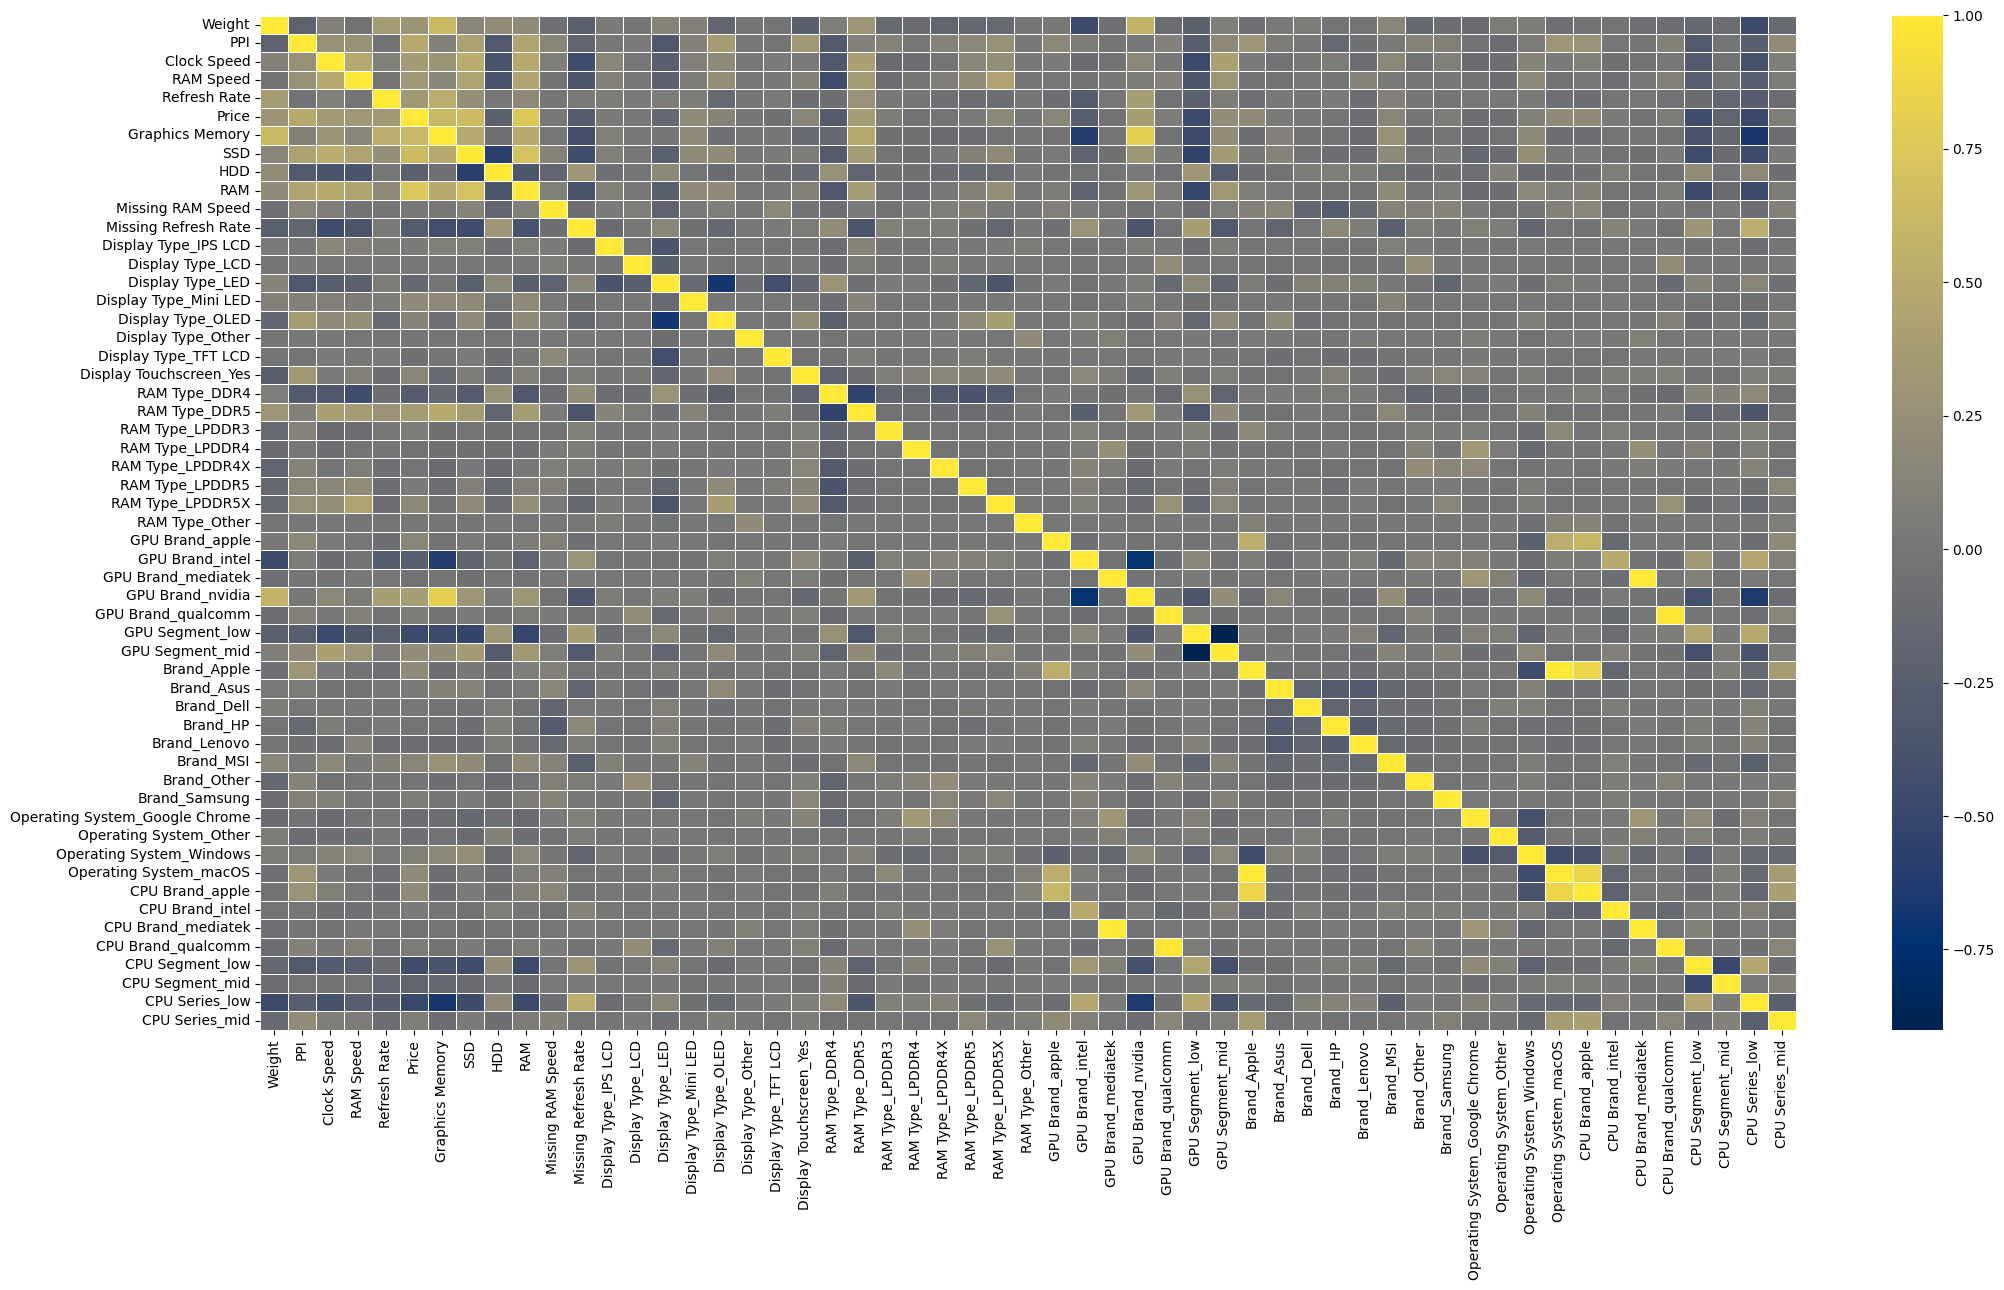

In [38]:
corr_df = preprocessed_df.corr()

plt.figure(figsize=(22,13))

sns.heatmap(corr_df, cmap='cividis', linewidths=0.5)

plt.tight_layout()
plt.show()

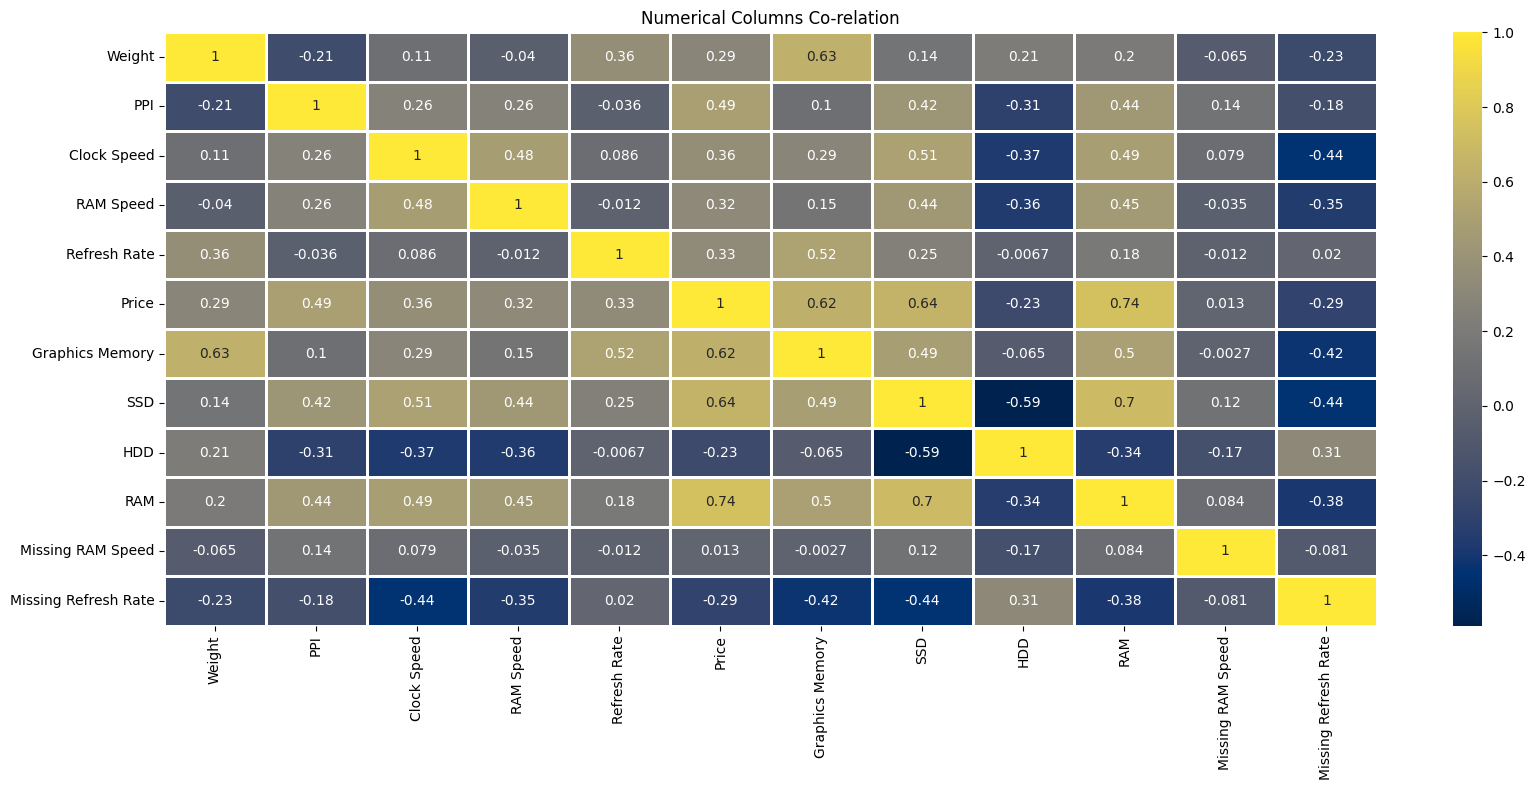

In [39]:
plt.figure(figsize=(17,8))

sns.heatmap(num_final_df.corr(), annot=True, cmap='cividis', linewidths=1)
plt.title('Numerical Columns Co-relation')

plt.tight_layout()
plt.show()

## Multicollinearity:

In [40]:
multicollinearity = preprocessed_df.drop(columns=['Price'])

vif = []

for i in range(multicollinearity.shape[1]):
    vif.append(variance_inflation_factor(multicollinearity, i))

vif_df = pd.DataFrame({'Features' : multicollinearity.columns,
             'VIF' : vif})

vif_df

,Features,VIF
0,Weight,38.418652
1,PPI,37.565914
2,Clock Speed,14.354917
3,RAM Speed,25.991518
4,Refresh Rate,19.826306
5,Graphics Memory,10.914722
6,SSD,10.707439
7,HDD,2.829704
8,RAM,10.334754
9,Missing RAM Speed,2.305022
